# Baseline sentiment model: TF-IDF + Logistic Regression

**Input:** `reviews_clean.csv` from the cleaning notebook
**Goal:** build a fast, interpretable baseline and evaluate it properly. The transformer (RoBERTa) will have to beat these numbers.

**Steps**
1. Load the cleaned data
2. Stratified train / validation / test split (and save it for the transformer notebook)
3. Two reference points: a "always positive" model
4. Build the TF-IDF + Logistic Regression pipeline
5. Tune on the validation set
6. Evaluate once on the test set: accuracy, precision, recall, F1, confusion matrix
7. Interpret the model: which words drive each class
8. Error analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

CLEAN_PATH = "reviews_clean.csv"   # output of the cleaning notebook; adjust if needed
SEED = 42
LABELS = ["negative", "neutral", "positive"]   # label ids 0, 1, 2

## 1. Load the cleaned data

In [2]:
df = pd.read_csv(CLEAN_PATH)
print(df.shape)
print(df["sentiment"].value_counts())
df[["text", "sentiment", "label"]].head()

(34597, 5)
sentiment
positive    32288
neutral      1499
negative      810
Name: count, dtype: int64


,text,sentiment,label
0,Kindle. This product so far has not disappoint...,positive,2
1,very fast. great for beginner or experienced p...,positive,2
2,Beginner tablet for our 9 year old son.. Inexp...,positive,2
3,Good!!!. I've had my Fire HD 8 two weeks now a...,positive,2
4,Fantastic Tablet for kids. I bought this for m...,positive,2


## 2. Stratified train / validation / test split (70 / 15 / 15)

Why three sets?
- **Train:** the model learns from it.
- **Validation:** we compare settings (such as the regularisation strength) on it.
- **Test:** touched **once**, at the very end, for the honest final score.

Why **stratified**? Negative reviews are only about 2% of the data. A random split could give the test set far fewer (or more) negatives than expected. Stratifying keeps the class proportions the same in all three sets.

In [3]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    share = part["sentiment"].value_counts(normalize=True).reindex(LABELS).round(3).to_dict()
    print(f"{name:5s} n={len(part):6d}  class share: {share}")

print("\nNegative / neutral reviews in the test set:",
      (test_df["label"] == 0).sum(), "/", (test_df["label"] == 1).sum())

train n= 24217  class share: {'negative': 0.023, 'neutral': 0.043, 'positive': 0.933}
val   n=  5190  class share: {'negative': 0.023, 'neutral': 0.043, 'positive': 0.933}
test  n=  5190  class share: {'negative': 0.024, 'neutral': 0.043, 'positive': 0.933}

Negative / neutral reviews in the test set: 122 / 225


The test set contains only about 120 negative and 225 neutral reviews, so per-class scores for those classes will be **noisy**. Keep this in mind when comparing models: small differences may just be chance.

We save the three splits so the transformer notebook can use exactly the same data. Otherwise the two models would not be comparable.

In [4]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

X_train, y_train = train_df["text"], train_df["label"]
X_val, y_val = val_df["text"], val_df["label"]
X_test, y_test = test_df["text"], test_df["label"]

## 3. Reference point: "always predict positive"

About 93% of reviews are positive, so a model that ignores the text entirely already reaches about 93% **accuracy**. This is why accuracy alone is misleading here, and why we use **macro-F1** (the average F1 over the three classes, each class counting equally) as the headline metric.

In [5]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred = dummy.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, pred):.3f}")
print(f"Macro-F1: {f1_score(y_val, pred, average='macro'):.3f}")

Accuracy: 0.933
Macro-F1: 0.322


High accuracy, but macro-F1 near 0.32: the model never finds a single negative or neutral review. Any real model has to beat that **macro-F1**, not the accuracy.

## 4. The pipeline: TF-IDF + Logistic Regression

- **TF-IDF** turns each review into a vector. Words that are frequent in a review but rare across all reviews get a higher weight, so common words like "the" count for little.
- **Unigrams + bigrams** (`ngram_range=(1, 2)`) let the model see phrases like "not good" or "stopped working".
- **`sublinear_tf`** dampens the effect of a word repeated many times, and **`min_df=2`** ignores words that appear in only one review.
- **`class_weight="balanced"`** makes mistakes on rare classes cost more, so the model doesn't just ignore negatives and neutrals.

In [6]:
def make_pipeline(ngram=(1, 2), C=1.0):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ngram, min_df=2, sublinear_tf=True,
                                  lowercase=True, strip_accents="unicode")),
        ("clf", LogisticRegression(C=C, class_weight="balanced",
                                   max_iter=1000, random_state=SEED)),
    ])

first = make_pipeline().fit(X_train, y_train)
pred = first.predict(X_val)
print(f"Validation accuracy: {accuracy_score(y_val, pred):.3f}")
print(f"Validation macro-F1: {f1_score(y_val, pred, average='macro'):.3f}")

Validation accuracy: 0.911
Validation macro-F1: 0.607


## 5. Tune on the validation set

We try a few settings and keep the one with the best **validation macro-F1**. The test set plays no part in this choice.

- `ngram_range`: single words only, or words and word pairs
- `C`: inverse regularisation strength. Small `C` means a simpler, more regularised model; large `C` means the model fits the training data more closely.

In [9]:
rows = []
for ngram in [(1, 1), (1, 2)]:
    for C in [0.1, 1, 10]:
        model = make_pipeline(ngram, C).fit(X_train, y_train)
        pred = model.predict(X_val)
        rows.append({"ngram": ngram, "C": C,
                     "val_accuracy": accuracy_score(y_val, pred),
                     "val_macro_f1": f1_score(y_val, pred, average="macro")})

results = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
results.round(3)

,ngram,C,val_accuracy,val_macro_f1
5,"(1, 2)",10.0,0.933,0.608
4,"(1, 2)",1.0,0.911,0.607
3,"(1, 2)",0.1,0.862,0.549
2,"(1, 1)",10.0,0.879,0.538
0,"(1, 1)",0.1,0.842,0.533
1,"(1, 1)",1.0,0.861,0.530


In [10]:
best = results.iloc[0]
best_ngram, best_C = best["ngram"], best["C"]
print("Best settings:", best_ngram, "C =", best_C)

final_model = make_pipeline(best_ngram, best_C).fit(X_train, y_train)

Best settings: (1, 2) C = 10.0


## 6. Final evaluation on the test set

This is the one and only time we look at the test set. Metrics:

- **Accuracy:** share of reviews classified correctly
- **Precision:** of the reviews predicted as a class, how many really belong to it
- **Recall:** of the reviews that truly belong to a class, how many we found
- **F1:** the harmonic mean of precision and recall
- **Macro-F1:** the unweighted mean of the per-class F1 scores

In [11]:
y_pred = final_model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"Test macro-F1: {f1_score(y_test, y_pred, average='macro'):.3f}\n")
print(classification_report(y_test, y_pred, target_names=LABELS, digits=3))

Test accuracy: 93.6%
Test macro-F1: 0.654

              precision    recall  f1-score   support

    negative      0.619     0.598     0.608       122
     neutral      0.383     0.387     0.385       225
    positive      0.969     0.970     0.969      4843

    accuracy                          0.936      5190
   macro avg      0.657     0.652     0.654      5190
weighted avg      0.936     0.936     0.936      5190



### Confusion matrix

Rows are the **true** class and columns the **predicted** class. The diagonal shows correct predictions. The right-hand plot is normalised by row, so each cell shows the share of that true class, which makes small classes readable.

               pred negative  pred neutral  pred positive
true negative             73            18             31
true neutral              20            87            118
true positive             25           122           4696


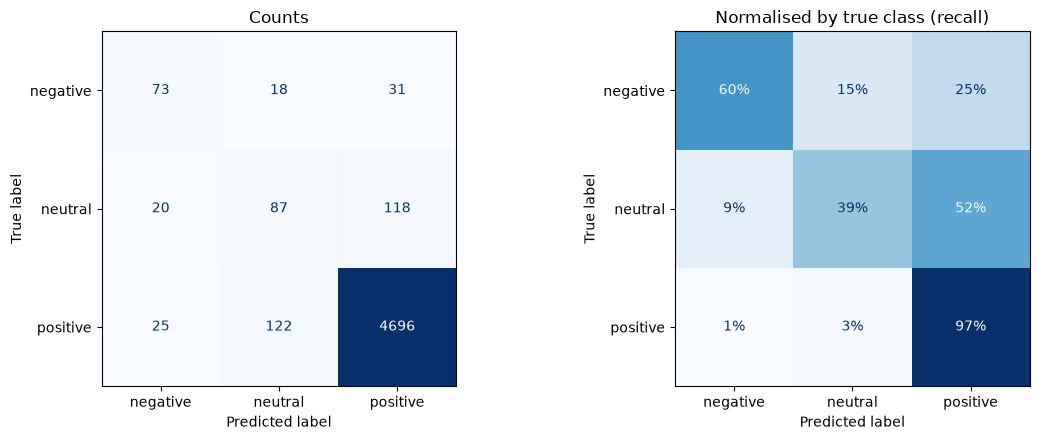

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=[f"true {l}" for l in LABELS],
                   columns=[f"pred {l}" for l in LABELS]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=LABELS, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Counts")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=LABELS, cmap="Blues", normalize="true",
    values_format=".0%", ax=axes[1], colorbar=False)
axes[1].set_title("Normalised by true class (recall)")
plt.tight_layout()
plt.show()

**How to read it:** look at each row of the normalised matrix. The diagonal value is that class's recall. The off-diagonal values show where the mistakes go. Expect neutral to bleed into both neighbours, because 3-star reviews are often a mix of praise and complaints.

## 7. What does the model look at?

For a linear model we can read the learned weights directly. These are the words and phrases that push a review toward each class, which is useful for the "help the company improve its products" angle.

In [13]:
tfidf = final_model.named_steps["tfidf"]
clf = final_model.named_steps["clf"]
vocab = np.array(tfidf.get_feature_names_out())

for i, name in enumerate(LABELS):
    top = np.argsort(clf.coef_[i])[-12:][::-1]
    print(f"{name.upper():9s}", ", ".join(vocab[top]))

NEGATIVE  not, good price, terrible, returned, not worth, one star, grandson he, disappointed, never, two stars, tablet nice, star
NEUTRAL   okay, ok, decent, for starter, but, sure, just not, three stars, product is, limited, can put, kids
POSITIVE  great, love, awesome, excellent, perfect, love it, fun, easy, easy to, amazing, best, well


The negative list is the most actionable for the company: these are the terms customers use when they complain.

## 8. Error analysis

Numbers hide *why* a model fails, so we read some actual mistakes. We look at the most costly ones: a negative review predicted as positive, and neutral reviews predicted as something else.

In [14]:
errors = test_df.assign(pred=[LABELS[i] for i in y_pred])
errors = errors[errors["sentiment"] != errors["pred"]]
print("Total errors:", len(errors), "of", len(test_df))

def show(true, pred, n=3):
    sub = errors[(errors["sentiment"] == true) & (errors["pred"] == pred)]
    print(f"\n--- true {true}, predicted {pred}: {len(sub)} reviews ---")
    for _, r in sub.sample(min(n, len(sub)), random_state=SEED).iterrows():
        print(f"[{r['rating']} stars] {r['text'][:300]}\n")

show("negative", "positive")
show("neutral", "positive")
show("positive", "neutral")

Total errors: 334 of 5190

--- true negative, predicted positive: 31 reviews ---
[2 stars] A little fun but not very useful. This is fun but would not buy again. Not very informative. Keeps say "I do not understand your question. "

[2 stars] Ugh worst ever! No memory. I purchased this as a after thought. The tablet has 8gb but from the moment you start to use it almost five is already used by Amazon I was totally disappointed. I love how the screen savers changed though it was so clear and unique but the memory took the cake for me!

[2 stars] Great price. Good value for the price, though a little slow loading some apps


--- true neutral, predicted positive: 118 reviews ---
[3 stars] Great for kids. Works as good as it should for the price. Its a little outdated...but for streaming tv and books its ok

[3 stars] Really good. i really like shopping at best buy in avon indiana

[3 stars] More apps more use. It takes practice and getting familiar with it. It is fun


--- true positive, 

Typical patterns to look for and write about:
- **Mixed reviews:** praise and complaints in the same text, where the star rating is a judgement call.
- **Sarcasm or negation:** a bag-of-words model misses these, which a transformer may handle better.
- **Label noise:** the text sounds positive but the rating is low, or the reverse. No model can fix this.

## Summary

Record these numbers, since the transformer will be compared against them:

| Model | Accuracy | Macro-F1 | Negative F1 | Neutral F1 | Positive F1 |
|---|---|---|---|---|---|
| Always positive | see section 3 | see section 3 | 0 | 0 | about 0.97 |
| TF-IDF + LR | section 6 | section 6 | section 6 | section 6 | section 6 |
| RoBERTa | next notebook | | | | |

**Next:** fine-tune `roberta-base` on the same `train.csv` / `val.csv`, evaluate on the same `test.csv`, and compare.